In [2]:
import os

os.listdir("data")

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [3]:
import pandas as pd

orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")

print("Orders shape:", orders.shape)
print("Order items shape:", order_items.shape)
print("Payments shape:", payments.shape)

Orders shape: (99441, 8)
Order items shape: (112650, 7)
Payments shape: (103886, 5)


In [4]:
#1durch copy
orders_clean = orders.copy()

In [5]:
#2info
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
#2describe
orders_clean.describe(include = "all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [7]:
#3Fehlende Werte (Missing Values) analysieren
orders_clean.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [8]:
#berechnen zusätzlich den prozentualen Anteil
anteil = round(orders_clean.isna().sum()/len(orders_clean)*100,2)
anteil

order_id                         0.00
customer_id                      0.00
order_status                     0.00
order_purchase_timestamp         0.00
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
order_estimated_delivery_date    0.00
dtype: float64

In [9]:
#4Duplikate prüfen
orders_clean.duplicated().sum()

np.int64(0)

In [10]:
#5Analyse der Bestellstatus
orders_clean["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [11]:
#6 Datensatz korrekt filtern
orders_clean = orders_clean[
orders_clean["order_status"] == "delivered"
].copy()

In [12]:
orders_clean.shape
orders_clean.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

Da der Anteil fehlender Werte unter 0.02% (14) liegt, werden diese Beobachtungen entfernt, um die Zeitreihenanalyse nicht zu verzerren. Also:

In [13]:
orders_clean = orders_clean.dropna()

In [14]:
orders_clean.shape
orders_clean.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [15]:
#7 Datumsfelder richtig formatieren

orders_clean["order_purchase_timestamp"] = pd.to_datetime(
    orders_clean["order_purchase_timestamp"]
)

orders_clean["order_delivered_customer_date"] = pd.to_datetime(
    orders_clean["order_delivered_customer_date"]
)

orders_clean["order_approved_at"] = pd.to_datetime(
    orders_clean["order_approved_at"]
)

orders_clean.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
dtype: object

In [16]:
#8 Berechnen Lieferzeit in Tagen

orders_clean["delivery_time_days"] = (
    orders_clean["order_delivered_customer_date"]
    - orders_clean["order_purchase_timestamp"]
).dt.days

orders_clean["delivery_time_days"].describe()

count    96455.000000
mean        12.093100
std          9.551209
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

In [17]:
#Ausreißer analysieren
#Maximum = 209 Tage - Das ist extrem hoch.
#Wie viele Lieferungen > 60 Tage?
orders_clean[orders_clean["delivery_time_days"] > 60].shape

(288, 9)

In [18]:
#Wie viele > 90 Tage?
orders_clean[orders_clean["delivery_time_days"] > 90].shape

(76, 9)

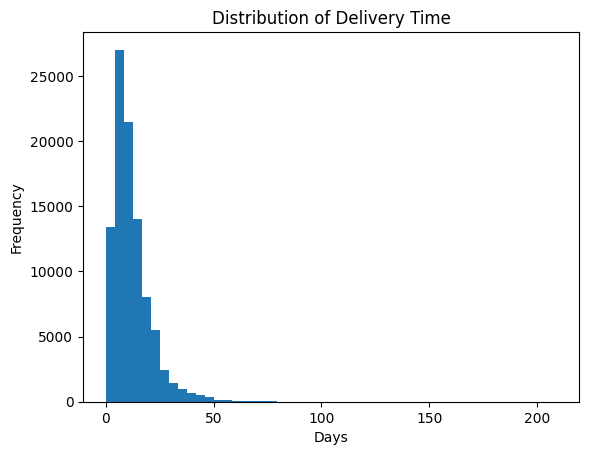

In [19]:
import matplotlib.pyplot as plt

plt.hist(orders_clean["delivery_time_days"], bins=50)
plt.title("Distribution of Delivery Time")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

Interpretation der Ausreißer:
60 Tage → 288 Bestellungen
90 Tage → 76 Bestellungen
Bei ~96.000 Bestellungen sind das:
288 ≈ 0,3%
76 ≈ 0,08%
Also extrem wenige.

Histogramm-Analyse
Stark rechtsschiefe Verteilung
Langer „Right Tail“
Mehrheit zwischen 5–20 Tagen
Das ist typisch für Logistikdaten.

Machen Hard Cut (z.B. > 60 Tage entfernen)
Sauber für Zeitreihen / Forecast
Realistisch für Business
Entfernen nur extreme Ausreißer:

In [20]:
orders_clean = orders_clean[
    orders_clean["delivery_time_days"] <= 60
]

In [21]:
orders_clean["delivery_time_days"].describe()

count    96167.000000
mean        11.865962
std          8.402958
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max         60.000000
Name: delivery_time_days, dtype: float64

In [22]:
orders_clean = orders_clean[
    orders_clean["delivery_time_days"] <= 60
]

orders_clean.shape

(96167, 9)

Vorher: ~96.455 Beobachtungen
Jetzt: 96.167 Bestellungen

nur ca. 288 Extremwerte entfernt (≈0,3%).

Das ist:

✔ statistisch sauber
✔ business-logisch
✔ transparent dokumentiert

# UMSATZ

In [23]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [24]:
#Umsatz pro Bestellung berechnen
order_items["total_price"] = (
    order_items["price"] + order_items["freight_value"]
)

revenue_per_order = order_items.groupby("order_id")[
    "total_price"
].sum().reset_index()

In [25]:
revenue_per_order.head()

,order_id,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [26]:
revenue_per_order.shape

(98666, 2)

In [27]:
#Mit orders_clean mergen
orders_clean = orders_clean.merge(
    revenue_per_order,
    on="order_id",
    how="left"
)

In [28]:
orders_clean["total_price"].describe()

count    96167.000000
mean       159.661743
std        218.643981
min          9.590000
25%         61.815000
50%        105.240000
75%        176.160000
max      13664.080000
Name: total_price, dtype: float64

In [29]:
orders_clean.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
delivery_time_days               0
total_price                      0
dtype: int64

Was sehen wir?

1Stark rechtsschiefe Verteilung
2Sehr hohe Max-Werte
3Mean deutlich höher als Median → typische E-Commerce-Verteilung
Das ist absolut realistisch.

Wichtige Business-Erkenntnis

In E-Commerce:
Wenige große Bestellungen treiben Umsatz
Mehrheit liegt im mittleren Bereich
Für Forecast nutzt man Gesamtumsatz, nicht Durchschnitt

Jetzt kommt der entscheidende Schritt

Wir bauen unsere Zeitreihe.

In [31]:
#1 Zeitraum der Daten prüfen
orders_clean["order_purchase_timestamp"].min()

Timestamp('2016-09-15 12:16:38')

In [32]:
orders_clean["order_purchase_timestamp"].max()

Timestamp('2018-08-29 15:00:37')

In [33]:
#2 Monatliche Zeitreihe erstellen (saubere monatliche Aggregation)
monthly_revenue = (
    orders_clean
    .set_index("order_purchase_timestamp")
    .resample("M")["total_price"]
    .sum()
)

C:\Users\Acer\AppData\Local\Temp\ipykernel_16932\3577587381.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["total_price"]


In [34]:
#3  Prüfen, ob Monate fehlen
monthly_revenue.isna().sum()

np.int64(0)

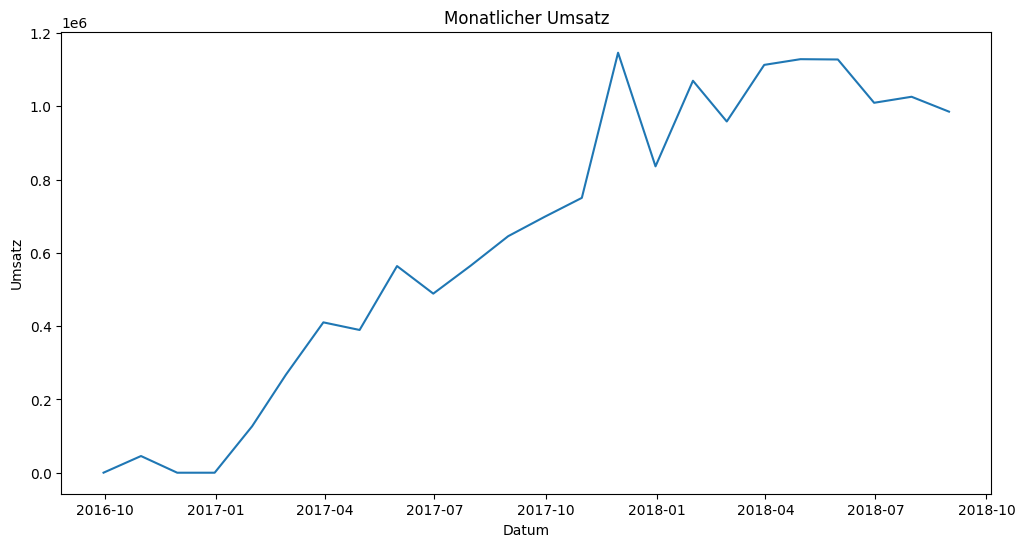

In [35]:
#4 Visualisierung der Zeitreihe
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_revenue)
plt.title("Monatlicher Umsatz")
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.show()

In [36]:
#5 – Augmented Dickey-Fuller Test (ADF)
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_revenue)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.4542526350496308
p-value: 0.5560084649642694


Mit einer p-value von 0.55 zeigt der ADF-Test klar, dass die Umsatzreihe nicht stationär ist und vor der Modellierung differenziert werden muss.

In [37]:
#6 Erste Differenz bilden
monthly_diff = monthly_revenue.diff().dropna()

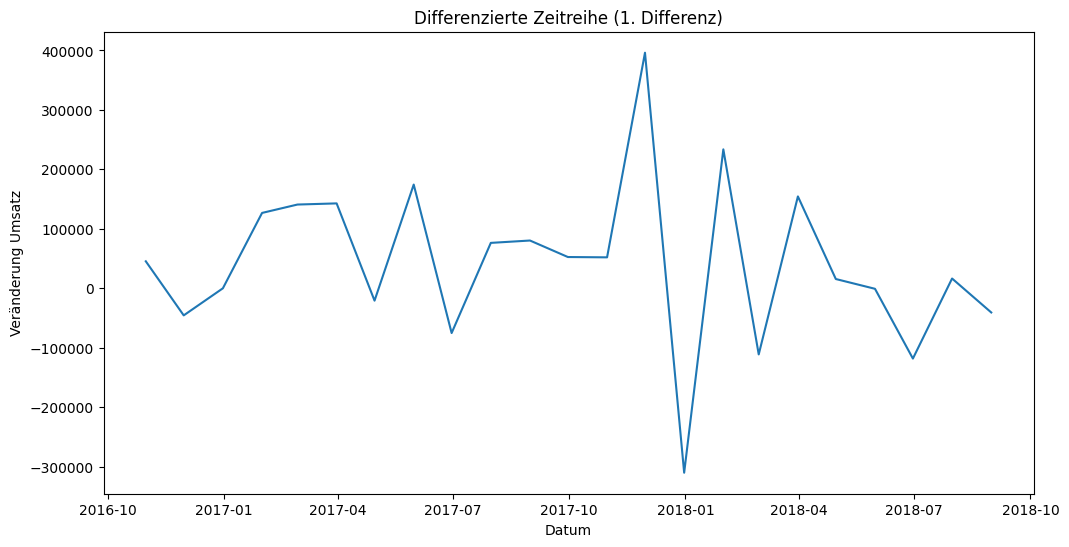

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_diff)
plt.title("Differenzierte Zeitreihe (1. Differenz)")
plt.xlabel("Datum")
plt.ylabel("Veränderung Umsatz")
plt.show()

In [39]:
result_diff = adfuller(monthly_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -8.321045726682712
p-value: 3.5719317576634753e-13


SARIMA(p, 1, q)(P, D, Q, s)
d = 1
erstellen ACF und PACF

<Figure size 1200x500 with 0 Axes>

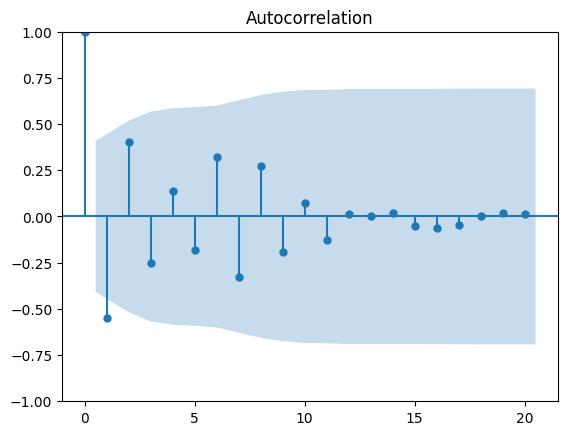

<Figure size 1200x500 with 0 Axes>

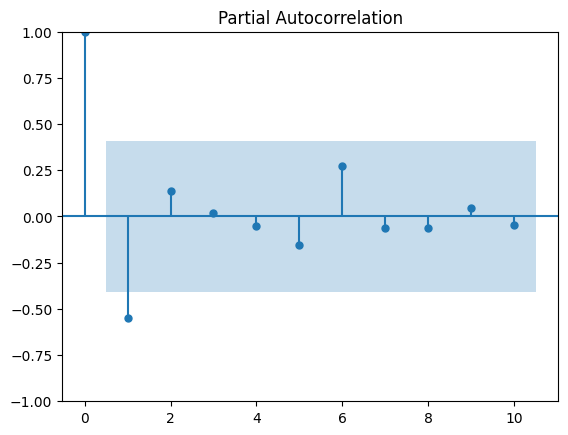

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plot_acf(monthly_diff, lags=20)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(monthly_diff, lags=10)
plt.show()

1 Aufteilung in Trainings- und Testdaten
Ziel:
prüfen, wie gut das Modell zukünftige Werte vorhersagen kann.
Dafür reservieren wir die letzten 6 Monate als Testperiode.

In [42]:
y = monthly_revenue.copy()

test_size = 6
train = y.iloc[:-test_size]
test  = y.iloc[-test_size:]

print("Train:", train.index.min(), "→", train.index.max(), "Anzahl:", len(train))
print("Test :", test.index.min(),  "→", test.index.max(),  "Anzahl:", len(test))

Train: 2016-09-30 00:00:00 → 2018-02-28 00:00:00 Anzahl: 18
Test : 2018-03-31 00:00:00 → 2018-08-31 00:00:00 Anzahl: 6


2 Funktion zur Modellschätzung und Bewertung
Wir definieren eine Funktion, um verschiedene ARIMA-Modelle objektiv vergleichen zu können.

In [43]:
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_arima_and_eval(train, test, order, seasonal_order=(0,0,0,0)):
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)

    # Prognose für Testperiode
    pred = res.get_forecast(steps=len(test))
    yhat = pred.predicted_mean

    # Bewertungsmetriken
    mae = np.mean(np.abs(test - yhat))
    rmse = np.sqrt(np.mean((test - yhat) ** 2))

    return res, yhat, mae, rmse

In [44]:
candidates = [(0,1,1), (1,1,0), (1,1,1)]

results_table = []
fitted = {}

for order in candidates:
    res, yhat, mae, rmse = fit_arima_and_eval(train, test, order=order)
    results_table.append({
        "Modell": str(order),
        "AIC": res.aic,
        "MAE": mae,
        "RMSE": rmse
    })
    fitted[order] = (res, yhat)

import pandas as pd
pd.DataFrame(results_table).sort_values(["RMSE","AIC"])

,Modell,AIC,MAE,RMSE
1,"(1, 1, 0)",430.725248,74021.259807,92746.089385
0,"(0, 1, 1)",406.344895,90779.651598,108526.025342
2,"(1, 1, 1)",404.620531,277801.541421,298391.193322


Für Prognosen ist RMSE entscheidend.
Warum?
RMSE misst den tatsächlichen Vorhersagefehler
Er wird auf der Testperiode berechnet
Er zeigt, wie gut das Modell wirklich vorhersagt
AIC ist wichtig, aber nur innerhalb der Trainingsdaten.

 Analyse
Modell (1,1,0)
RMSE = 92.746 → bester Wert
MAE oderat
AIC nicht der niedrigste, aber akzeptabel

Modell (0,1,1)
RMSE deutlich höher
Schlechtere Prognoseleistung

Modell (1,1,1)
Niedrigster AIC (gut im Training)
ABER extrem hoher RMSE
Stark overfitted
Das Modell passt Trainingsdaten gut,
aber generalisiert schlecht auf neue Daten.

Fazit
ARIMA(1,1,0) ist das optimale Modell.
Warum?
Niedrigster Prognosefehler (RMSE)
Stabilere Vorhersage
Keine Überanpassung
Bessere Generalisierung

In [ ]:
#5 Finale Modellierung mit ARIMA(1,1,0)

In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_model = SARIMAX(
    y,
    order=(1,1,0),
    seasonal_order=(0,0,0,0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_res = final_model.fit(disp=False)

print(final_res.summary())

                               SARIMAX Results                                
Dep. Variable:            total_price   No. Observations:                   24
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -290.878
Date:                Tue, 03 Mar 2026   AIC                            585.756
Time:                        22:27:33   BIC                            587.938
Sample:                    09-30-2016   HQIC                           586.270
                         - 08-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4110      0.215     -1.908      0.056      -0.833       0.011
sigma2      1.786e+10    3.7e-12   4.82e+21      0.000    1.79e+10    1.79e+10
Ljung-Box (L1) (Q):                   0.28   Jarque-

In [46]:
#6-Monats-Prognose
forecast_steps = 6
fc = final_res.get_forecast(steps=forecast_steps)

fc_mean = fc.predicted_mean
fc_ci = fc.conf_int()

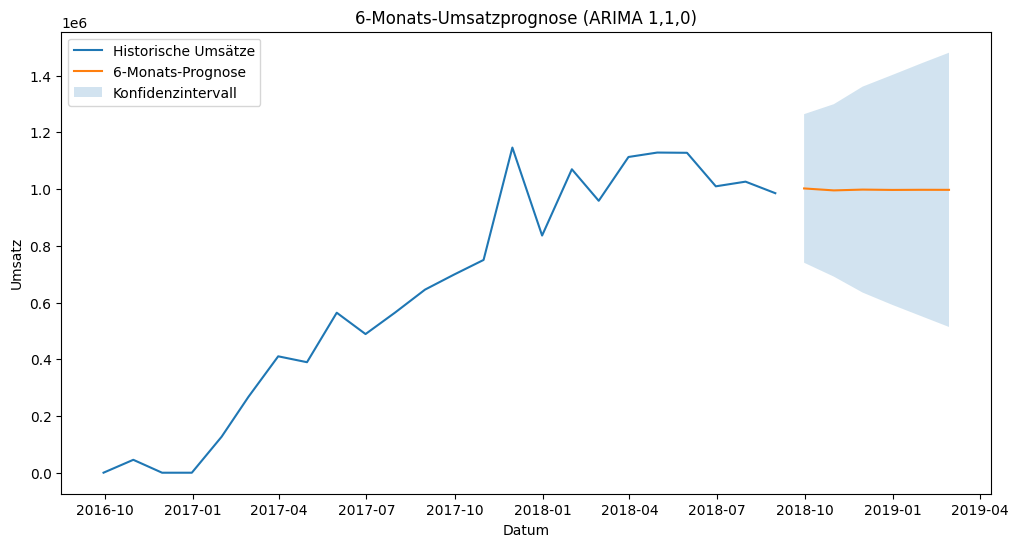

In [47]:
#Visualisierung
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y.index, y.values, label="Historische Umsätze")

plt.plot(fc_mean.index, fc_mean.values, label="6-Monats-Prognose")

plt.fill_between(fc_ci.index,
                 fc_ci.iloc[:,0],
                 fc_ci.iloc[:,1],
                 alpha=0.2,
                 label="Konfidenzintervall")

plt.title("6-Monats-Umsatzprognose (ARIMA 1,1,0)")
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.show()

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_trend = SARIMAX(
    y,
    order=(1,1,0),
    seasonal_order=(0,0,0,0),
    trend="t",  # линейный тренд
    enforce_stationarity=False,
    enforce_invertibility=False
)

res_trend = model_trend.fit(disp=False)

print(res_trend.summary())

                               SARIMAX Results                                
Dep. Variable:            total_price   No. Observations:                   24
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -289.763
Date:                Tue, 03 Mar 2026   AIC                            585.525
Time:                        22:32:12   BIC                            588.798
Sample:                    09-30-2016   HQIC                           586.296
                         - 08-31-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
drift       3072.5457   2204.725      1.394      0.163   -1248.637    7393.728
ar.L1         -0.4776      0.225     -2.126      0.033      -0.918      -0.037
sigma2       1.63e+10      0.001   2.73e+13      0.0

In [49]:
forecast_steps = 6
fc_trend = res_trend.get_forecast(steps=forecast_steps)

fc_mean_trend = fc_trend.predicted_mean
fc_ci_trend = fc_trend.conf_int()

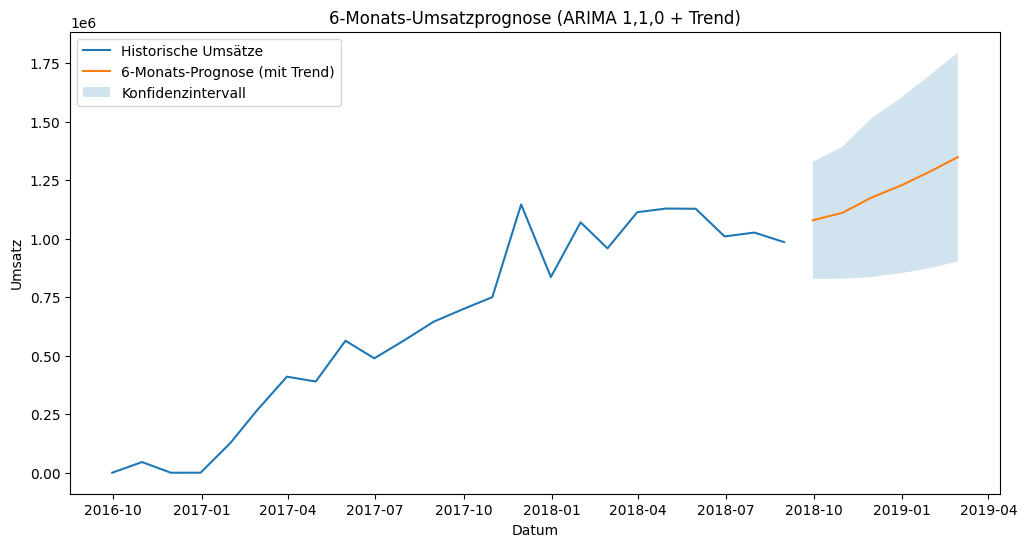

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y.index, y.values, label="Historische Umsätze")

plt.plot(fc_mean_trend.index, fc_mean_trend.values,
         label="6-Monats-Prognose (mit Trend)")

plt.fill_between(fc_ci_trend.index,
                 fc_ci_trend.iloc[:,0],
                 fc_ci_trend.iloc[:,1],
                 alpha=0.2,
                 label="Konfidenzintervall")

plt.title("6-Monats-Umsatzprognose (ARIMA 1,1,0 + Trend)")
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.show()

In [ ]:
#Log_ARIMA

C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


order_purchase_timestamp
2016-09-30     4.966056
2016-10-31    10.726553
2016-11-30         -inf
2016-12-31     2.976549
2017-01-31    11.750113
Freq: ME, Name: total_price, dtype: float64

In [56]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fit_arima_log(train, test, order, trend=None):
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=(0,0,0,0),
        trend=trend,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    pred = res.get_forecast(steps=len(test)).predicted_mean

    mae = np.mean(np.abs(test - pred))
    rmse = np.sqrt(np.mean((test - pred) ** 2))
    return res, pred, mae, rmse

candidates = [
    ((1,1,0), "t"),
    ((0,1,1), None),
    ((1,1,1), None)
]

rows = []
fitted_log = {}

for order, trend in candidates:
    res, pred, mae, rmse = fit_arima_log(train_log, test_log, order=order, trend=trend)
    rows.append({"model": f"{order}, trend={trend}", "AIC": res.aic, "MAE_log": mae, "RMSE_log": rmse})
    fitted_log[(order, trend)] = (res, pred)

pd.DataFrame(rows).sort_values(["RMSE_log","AIC"])

C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:859: RuntimeWarning: invalid value encountered in dot
  params = np.linalg.pinv(X).dot(Y)
C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\User

,model,AIC,MAE_log,RMSE_log
0,"(1, 1, 0), trend=t",NaN,NaN,NaN
1,"(0, 1, 1), trend=None",NaN,NaN,NaN
2,"(1, 1, 1), trend=None",NaN,NaN,NaN


In [58]:
y_log = np.log1p(y)

model_log = SARIMAX(
    y_log,
    order=(1,1,0),
    trend="t",
    enforce_stationarity=False,
    enforce_invertibility=False
)

res_log = model_log.fit(disp=False)

print("AIC (log model):", res_log.aic)

AIC (log model): 115.28447077267055


In [62]:
forecast_steps = 6

forecast_log = res_log.get_forecast(steps=forecast_steps)

forecast_mean_log = forecast_log.predicted_mean
forecast_ci_log = forecast_log.conf_int()

In [63]:
forecast_mean = np.expm1(forecast_mean_log)
forecast_lower = np.expm1(forecast_ci_log.iloc[:, 0])
forecast_upper = np.expm1(forecast_ci_log.iloc[:, 1])

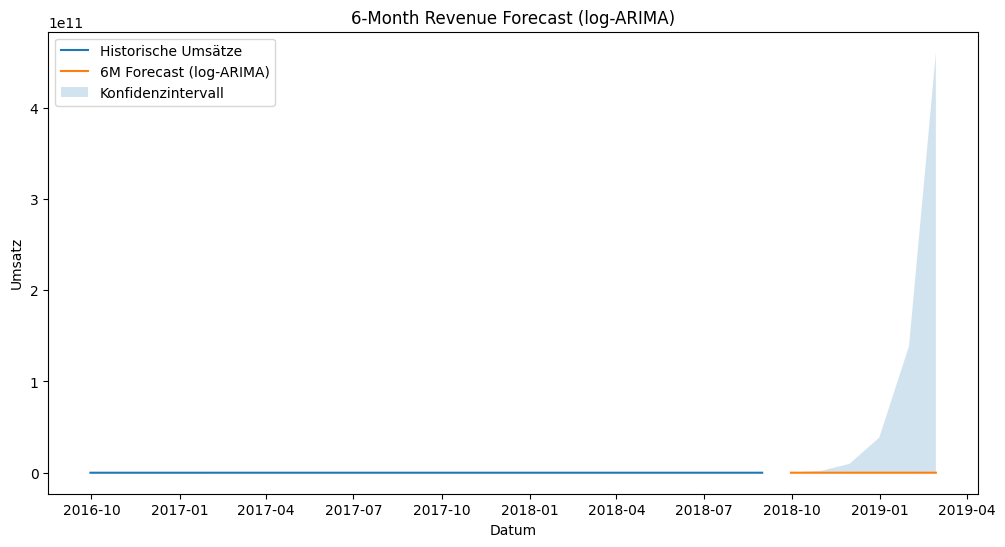

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y.index, y.values, label="Historische Umsätze")

plt.plot(forecast_mean.index,
         forecast_mean.values,
         label="6M Forecast (log-ARIMA)")

plt.fill_between(forecast_mean.index,
                 forecast_lower.values,
                 forecast_upper.values,
                 alpha=0.2,
                 label="Konfidenzintervall")

plt.title("6-Month Revenue Forecast (log-ARIMA)")
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.show()